# LinkedIn ML Selector: Who to Scrape Next

This notebook ranks **normal users** for the next scraping batch using **graph-based ML** over your LinkedIn network.

We will:
- Load your scraped posts + followers + connections.
- Build a directed graph with edge types: FOLLOWER / CONNECTION / TAG / REPOST.
- Engineer graph features for each profile (relationship counts, centralities, PageRank).
- Define a **reward** from historical posts (e.g. mean engagement per author).
- Train an **XGBoost regressor** to predict expected scraping value from graph features.
- Select the **top K users to scrape next** by predicted value.

In [92]:
import json
from pathlib import Path
from ast import literal_eval

from sklearn.svm import OneClassSVM
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from xgboost import XGBRegressor

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

ROOT_DIR = Path("/home/martin/technical-news")
NOTEBOOKS_DIR = ROOT_DIR / "notebooks"

# Define data path resposts, tags, follower and connection information
CSV_PATH = NOTEBOOKS_DIR / "linkedin_scraping_data_20260203_191729.csv"
FOLLOWERS_PATH = NOTEBOOKS_DIR / "all_scraped_followers.json"
CONNECTIONS_PATH = NOTEBOOKS_DIR / "all_scraped_connections.json"

In [93]:
# Load raw data

posts_df = pd.read_csv(CSV_PATH)

with open(FOLLOWERS_PATH, "r", encoding="utf-8") as f:
    followers_data = json.load(f)

with open(CONNECTIONS_PATH, "r", encoding="utf-8") as f:
    connections_data = json.load(f)

print("Posts:", posts_df.shape)
print("Followers influencers:", followers_data.get("total_influencers"))
print("Connections influencers:", connections_data.get("total_influencers"))

posts_df.head(3)

Posts: (130, 21)
Followers influencers: 46
Connections influencers: 46


,post_url,activity_id,text,topic,supported_industry,keywords,reactions,comments,reposts,tagged_profiles,...,original_author,media_url,time_ago,scraped_at,engagement_score,author,influencer_name,influencer_title,followers_count,is_tech_related
0,https://www.linkedin.com/feed/update/urn:li:ac...,7422753343413895168,I built a tool to help me stay-up-date with ne...,['Generative AI'],['Technology'],ai,3370,130,187,[],...,NaN,https://media.licdn.com/dms/image/v2/D5622AQF5...,4d,2026-02-03T12:17:42.588520,3687,chiphuyen,Chip Huyen,AI x stuff,"303,333",True
1,https://www.linkedin.com/feed/update/urn:li:ac...,7358971409227792384,What people think will improve AI applications...,['Orchestration'],['Technology'],database,2132,107,184,[],...,NaN,https://media.licdn.com/dms/image/v2/D5622AQFs...,5m,2026-02-03T12:17:42.600294,2423,chiphuyen,Chip Huyen,AI x stuff,"303,333",True
2,https://www.linkedin.com/feed/update/urn:li:ac...,7389740123669721088,Had a great time chatting with Lenny Rachitsky...,['Generative AI'],['Technology'],api,766,57,41,['https://www.linkedin.com/in/lennyrachitsky/'],...,NaN,\N,3m,2026-02-03T12:17:42.595835,864,chiphuyen,Chip Huyen,AI x stuff,"303,333",True


In [94]:
# Helper functions

def linkedin_slug_from_url(url: str | None) -> str | None:
    """Extract the profile slug from a LinkedIn URL like https://www.linkedin.com/in/slug/.
    Returns None for missing/invalid URLs.
    """
    if not isinstance(url, str) or not url:
        return None
    if "linkedin.com" not in url:
        return None
    try:
        parts = url.split("/")
        # find "in" segment and take the next one
        for i, p in enumerate(parts):
            if p == "in":
                if i + 1 < len(parts):
                    return parts[i + 1] or None
        # fallback: last non-empty segment
        for p in reversed(parts):
            if p:
                return p
    except Exception:
        return None
    return None


def safe_parse_list(value):
    """Parse list-like strings from the CSV safely.

    Examples:
    - "[]" -> []
    - "['https://www.linkedin.com/in/foo/']" -> ["https://www.linkedin.com/in/foo/"]
    - NaN / '\\N' -> []
    """
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        v = value.strip()
        if v in ("", "[]", "\\N", "null", "None"):
            return []
        try:
            parsed = literal_eval(v)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return []
    return []

In [95]:
# Build NetworkX graph from followers, connections, tags, and reposts

G = nx.DiGraph()

# 3.1 Seed influencers from JSON (treated as influencer nodes)
seed_slugs = set()

for inf in followers_data.get("influencers", []):
    inf_name = inf.get("influencer")
    inf_url = inf.get("influencer_url")
    slug = linkedin_slug_from_url(inf_url)
    if not slug:
        continue
    seed_slugs.add(slug)
    G.add_node(slug, name=inf_name, url=inf_url, role="influencer")

for inf in connections_data.get("influencers", []):
    inf_name = inf.get("influencer")
    inf_url = inf.get("influencer_url")
    slug = linkedin_slug_from_url(inf_url)
    if not slug:
        continue
    seed_slugs.add(slug)
    if slug not in G:
        G.add_node(slug, name=inf_name, url=inf_url, role="influencer")

print(f"Total seed influencers: {len(seed_slugs)}")

# 3.2 Followers: edges influencer -> follower (type=FOLLOWER)
for inf in followers_data.get("influencers", []):
    inf_url = inf.get("influencer_url")
    src_slug = linkedin_slug_from_url(inf_url)
    if not src_slug:
        continue
    for fol in inf.get("followers", []):
        fol_name = fol.get("follower_name")
        fol_url = fol.get("follower_url")
        fol_title = fol.get("follower_title")
        dst_slug = linkedin_slug_from_url(fol_url)
        if not dst_slug:
            continue
        if dst_slug not in G:
            G.add_node(dst_slug, name=fol_name, url=fol_url, role="user", title=fol_title)
        else:
            # Enrich existing node with title if missing
            node = G.nodes[dst_slug]
            if not node.get("title"):
                node["title"] = fol_title
        G.add_edge(src_slug, dst_slug, type="FOLLOWER")

# 3.3 Connections: edges influencer -> connection (type=CONNECTION)
for inf in connections_data.get("influencers", []):
    inf_url = inf.get("influencer_url")
    src_slug = linkedin_slug_from_url(inf_url)
    if not src_slug:
        continue
    for conn in inf.get("connections", []):
        conn_name = conn.get("connection_name")
        conn_url = conn.get("connection_url")
        conn_title = conn.get("connection_title")
        dst_slug = linkedin_slug_from_url(conn_url)
        if not dst_slug:
            continue
        if dst_slug not in G:
            G.add_node(dst_slug, name=conn_name, url=conn_url, role="user", title=conn_title)
        else:
            node = G.nodes[dst_slug]
            if not node.get("title"):
                node["title"] = conn_title
        G.add_edge(src_slug, dst_slug, type="CONNECTION")

# 3.4 Tags & reposts from posts CSV

# Normalize tagged_profiles column
if "tagged_profiles" in posts_df.columns:
    posts_df["tagged_profiles_parsed"] = posts_df["tagged_profiles"].apply(safe_parse_list)
else:
    posts_df["tagged_profiles_parsed"] = [[] for _ in range(len(posts_df))]

for _, row in posts_df.iterrows():
    author_slug = str(row.get("author", "")).strip().lower() or None
    if author_slug and author_slug not in G:
        G.add_node(
            author_slug,
            name=row.get("influencer_name", author_slug),
            url=None,
            role="influencer" if author_slug in seed_slugs else "user",
        )

    # TAG edges: author -> tagged profile
    for url in row["tagged_profiles_parsed"]:
        dst_slug = linkedin_slug_from_url(url)
        if not dst_slug:
            continue
        if dst_slug not in G:
            G.add_node(dst_slug, name=None, url=url, role="user")
        if author_slug:
            G.add_edge(author_slug, dst_slug, type="TAG")

    # REPOST edges: author -> original_author
    is_repost = row.get("is_repost", False)
    original_author_url = row.get("original_author")
    if is_repost and isinstance(original_author_url, str) and original_author_url not in ("", "\\N"):
        dst_slug = linkedin_slug_from_url(original_author_url)
        if dst_slug:
            if dst_slug not in G:
                G.add_node(dst_slug, name=None, url=original_author_url, role="user")
            if author_slug:
                G.add_edge(author_slug, dst_slug, type="REPOST")

print(f"Graph nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

edge_types = [d.get("type", "UNKNOWN") for _, _, d in G.edges(data=True)]
print("Edge type counts:", pd.Series(edge_types).value_counts().to_dict())

Total seed influencers: 46
Graph nodes: 4282, edges: 4730
Edge type counts: {'CONNECTION': 2405, 'FOLLOWER': 2164, 'TAG': 144, 'REPOST': 17}


In [96]:
# 4. Global graph features (centralities)

G_undirected = G.to_undirected()

#in_deg_cent  = nx.in_degree_centrality(G)
#out_deg_cent = nx.out_degree_centrality(G)
closeness_cent = nx.closeness_centrality(G_undirected)
pagerank = nx.pagerank(G, alpha=0.85)

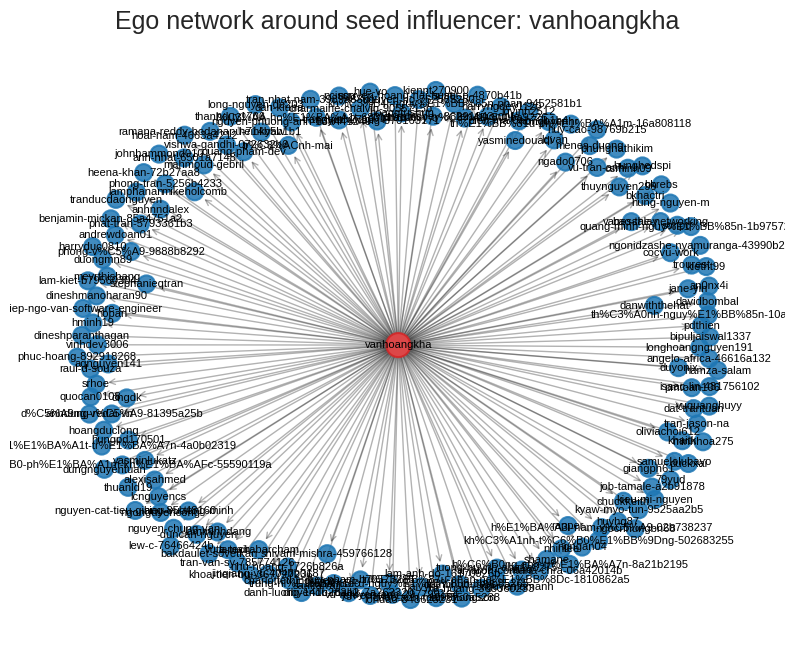

In [97]:
# 4. Visualize a small slice of the graph (one influencer ego network)

# Pick a seed with the highest out-degree (most relationships)
seed_degrees = sorted(
    ((s, G.out_degree(s)) for s in seed_slugs if s in G),
    key=lambda x: x[1],
    reverse=True,
)

if seed_degrees:
    top_seed, _ = seed_degrees[0]
    ego = nx.ego_graph(G, top_seed, radius=1, center=True)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(ego, seed=42)

    node_colors = ["tab:red" if n in seed_slugs else "tab:blue" for n in ego.nodes]
    node_sizes = [300 if n in seed_slugs else 150 for n in ego.nodes]

    nx.draw_networkx_nodes(ego, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(ego, pos, alpha=0.3, arrows=True, arrowstyle="->", arrowsize=10)

    labels = {n: n for n in ego.nodes}
    nx.draw_networkx_labels(ego, pos, labels=labels, font_size=8)

    plt.title(f"Ego network around seed influencer: {top_seed}")
    plt.axis("off")
    plt.show()
else:
    print("No seed influencers found in graph for visualization.")

In [98]:
# 5. Feature engineering: relationship counts from seed influencers

EDGE_TYPES = ["REPOST", "TAG", "CONNECTION", "FOLLOWER"]


def extract_relationship_features(slug: str) -> dict:
    counts = {f"num_{t.lower()}_edges": 0 for t in EDGE_TYPES}

    if slug not in G:
        return counts

    for src, dst, data in G.in_edges(slug, data=True):
        if src not in seed_slugs:
            continue
        etype = data.get("type")
        key = f"num_{etype.lower()}_edges" if etype in EDGE_TYPES else None
        if key in counts:
            counts[key] += 1

    return counts


rows = []

for slug in G.nodes:
    feats = extract_relationship_features(slug)
    total_rels = sum(feats.values())
    is_seed = slug in seed_slugs

    rows.append({
        "slug": slug,
        "is_seed": is_seed,
        "total_relationships": total_rels,
        **feats,
        "closeness_centrality":  closeness_cent.get(slug, 0.0),
        "pagerank":              pagerank.get(slug, 0.0),
    })

features_df = pd.DataFrame(rows)
print("Features shape:", features_df.shape)
features_df.head(100)

Features shape: (4282, 9)


,slug,is_seed,total_relationships,num_repost_edges,num_tag_edges,num_connection_edges,num_follower_edges,closeness_centrality,pagerank
0,chiphuyen,True,1,0,0,1,0,0.260144,0.000233
1,yann-lecun,True,0,0,0,0,0,0.243381,0.000231
2,alexxubyte,True,0,0,0,0,0,0.216474,0.000231
3,andrewyng,True,0,0,0,0,0,0.248023,0.000231
4,vanhoangkha,True,8,0,0,0,8,0.264693,0.000244
...,...,...,...,...,...,...,...,...,...
95,an-nguyen-7904a81ab,False,1,0,0,0,1,0.204297,0.000233
96,sanhlx,False,3,0,0,0,3,0.219230,0.000236
97,h%C6%B0ng-%C4%91%C3%A0o-th%C3%A0nh-ab74501b0,False,2,0,0,0,2,0.215823,0.000234
98,phunguyentrong,False,1,0,0,0,1,0.204297,0.000233


In [99]:
# 6. Train/test split (given features) + regression model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
import math

feature_cols = [
    "num_repost_edges",
    "num_tag_edges",
    "num_connection_edges",
    "num_follower_edges",
    "closeness_centrality",
    "pagerank",
]

def _slug_norm(v):
    if v is None:
        return None
    s = str(v).strip().lower()
    if not s:
        return None
    if "/in/" in s:
        s = s.rstrip("/").split("/in/")[-1].split("?")[0]
    return s.strip("/") or None

def _is_technical_row(row):
    if "is_tech_related" in row and pd.notna(row["is_tech_related"]):
        return bool(row["is_tech_related"])
    topics = row.get("topic", [])
    if isinstance(topics, str):
        topics = [topics]
    elif not hasattr(topics, "__iter__"):
        topics = [topics]
    topics_norm = [str(t).strip().lower() for t in topics if str(t).strip()]
    if not topics_norm:
        return False
    return "non-technical" not in topics_norm

def build_regression_outcomes(posts_df):
    w = posts_df.copy()
    if w.empty or "author" not in w.columns:
        return pd.DataFrame(columns=["slug", "target"])
    w = w[w.apply(_is_technical_row, axis=1)].copy()
    if w.empty:
        return pd.DataFrame(columns=["slug", "target"])
    if "engagement_score" in w.columns:
        w["engagement"] = pd.to_numeric(w["engagement_score"], errors="coerce").fillna(0.0)
    else:
        for col in ["reactions", "comments", "reposts"]:
            if col not in w.columns:
                w[col] = 0
            w[col] = pd.to_numeric(w[col], errors="coerce").fillna(0.0)
        w["engagement"] = w["reactions"] + w["comments"] + w["reposts"]
    w["target"] = np.log1p(w["engagement"])
    w["slug"] = w["author"].apply(_slug_norm)
    w = w[w["slug"].notna()]
    return w.groupby("slug", as_index=False)["target"].mean()

def ndcg_at_k(y_true, y_pred, k):
    order = np.argsort(-y_pred)
    rel = y_true[order][:k]
    dcg = sum(v / math.log2(i + 2) for i, v in enumerate(rel))
    ideal = np.sort(y_true)[::-1][:k]
    idcg = sum(v / math.log2(i + 2) for i, v in enumerate(ideal))
    return float(dcg / idcg) if idcg > 0 else 0.0

def yield_at_k(y_true, y_pred, k):
    order = np.argsort(-y_pred)
    return float(np.sum(y_true[order][:k]))

outcomes_df = build_regression_outcomes(posts_df)
reg_df = features_df.merge(outcomes_df, on="slug", how="inner").dropna(subset=feature_cols + ["target"]).copy()
if len(reg_df) < 12:
    raise ValueError(f"Not enough labeled rows for train/test split: {len(reg_df)}")

X = reg_df[feature_cols].values
y = reg_df["target"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Rows with targets: {len(reg_df)} | train={len(y_train)} test={len(y_test)}")

models = {
    "XGBoost": XGBRegressor(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective="reg:squarederror", random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    "Ridge": Ridge(alpha=1.0),
}

k_values = [k for k in [5, 10, 20] if k <= len(y_test)] or [len(y_test)]
rows = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained_models[name] = model
    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    r2 = r2_score(y_test, pred)
    for k in k_values:
        rows.append({
            "model": name,
            "k": int(k),
            "mae": float(mae),
            "rmse": float(rmse),
            "r2": float(r2),
            "ndcg_at_k": ndcg_at_k(y_test, pred, k),
            "yield_at_k": yield_at_k(y_test, pred, k),
        })

metrics_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
print("Evaluation metrics by model and K:")
display(metrics_df)

summary_df = metrics_df.groupby("model", as_index=False).agg(
    mean_ndcg_at_k=("ndcg_at_k", "mean"),
    mean_yield_at_k=("yield_at_k", "mean"),
    mean_rmse=("rmse", "mean"),
    mean_mae=("mae", "mean"),
    mean_r2=("r2", "mean"),
)
summary_df = summary_df.sort_values(["mean_ndcg_at_k", "mean_yield_at_k", "mean_rmse"], ascending=[False, False, True]).reset_index(drop=True)

best_model = summary_df.loc[0, "model"]
best_regressor = trained_models[best_model]
print(f"Selected best model for next-batch ranking: {best_model}")
display(summary_df)


Rows with targets: 36 | train=25 test=11
Evaluation metrics by model and K:


,model,k,mae,rmse,r2,ndcg_at_k,yield_at_k
0,RandomForest,5,2.238113,2.437742,-0.543709,0.840462,31.017102
1,Ridge,5,1.786600,2.232171,-0.294329,0.719589,24.480520
2,XGBoost,5,1.983962,2.216099,-0.275758,0.787199,26.894124
3,RandomForest,10,2.238113,2.437742,-0.543709,0.849645,47.337596
4,Ridge,10,1.786600,2.232171,-0.294329,0.840633,47.337596
5,XGBoost,10,1.983962,2.216099,-0.275758,0.845376,46.480495


Selected best model for next-batch ranking: RandomForest


,model,mean_ndcg_at_k,mean_yield_at_k,mean_rmse,mean_mae,mean_r2
0,RandomForest,0.845053,39.177349,2.437742,2.238113,-0.543709
1,XGBoost,0.816287,36.687309,2.216099,1.983962,-0.275758
2,Ridge,0.780111,35.909058,2.232171,1.786600,-0.294329


In [100]:
# 7. Select Top-K users for next scraping batch using the best model
TOP_K_NEXT = 60

rank_df = features_df.copy()
rank_df["predicted_tech_potential"] = best_regressor.predict(rank_df[feature_cols].values)

next_batch_df = rank_df[(~rank_df["is_seed"]) & (rank_df["total_relationships"] > 0)].copy()
next_batch_df = next_batch_df.sort_values("predicted_tech_potential", ascending=False)
next_batch_df["name"] = next_batch_df["slug"].map(lambda s: G.nodes.get(s, {}).get("name"))
next_batch_df["url"] = next_batch_df["slug"].map(lambda s: G.nodes.get(s, {}).get("url"))

cols = [
    "slug", "name", "url", "predicted_tech_potential",
    "num_repost_edges", "num_tag_edges", "num_connection_edges", "num_follower_edges",
]

print(f"Top {TOP_K_NEXT} users for next scraping batch ({best_model}):")
display(next_batch_df[cols].head(TOP_K_NEXT))


Top 60 users for next scraping batch (RandomForest):


,slug,name,url,predicted_tech_potential,num_repost_edges,num_tag_edges,num_connection_edges,num_follower_edges
1881,chau-huynh-951a55136,chau huynh,https://www.linkedin.com/in/chau-huynh-951a55136,8.567415,0,0,2,0
1938,remi-el-ouazzane-6a1111,Remi El-Ouazzane,https://www.linkedin.com/in/remi-el-ouazzane-6...,8.567415,0,0,3,0
1906,chaoyi-zhang,Chaoyi Z.,https://www.linkedin.com/in/chaoyi-zhang,8.567415,0,0,2,0
76,dzungdam512,Dzung Dam,https://www.linkedin.com/in/dzungdam512,8.553423,0,0,0,2
151,van-an-hoang,An Hoang,https://www.linkedin.com/in/van-an-hoang,8.553423,0,0,0,2
142,konjluu,Công Lưu,https://www.linkedin.com/in/konjluu,8.553423,0,0,0,2
199,sachinpr,Sachin Raikar,https://www.linkedin.com/in/sachinpr,8.553423,0,0,0,2
1217,minhaohao,Hao Luong,https://www.linkedin.com/in/minhaohao,8.553423,0,0,0,2
170,tanminhtran168,Minh Tran Tan,https://www.linkedin.com/in/tanminhtran168,8.553423,0,0,0,2
58,thaoanh147,Thao Anh Tran,https://www.linkedin.com/in/thaoanh147,8.553423,0,0,0,2
